# 06 - Live demo (2-3 minutes)
1. Retrain and score the held-out quarter from code. 2. Recompute the targeting result from the prediction file.
3. Explain one member's score. 4. Ask the model a retention what-if.

**Before recording:** run `python run_pipeline.py --no-notebooks` once (about 1.5 minutes): this notebook loads the
trained models. Then *Kernel -> Restart Kernel and Run All Cells*. Values in CAPITALS can be changed live.

In [1]:
%matplotlib inline
from churn.notebook import *   # pandas as pd, numpy as np, display, Markdown, fig(), tab(), run_step(), paths P
import joblib
import matplotlib.pyplot as plt
from churn import config as C, feature_engineering as FE, final_model as FM, plotting as pl, scenarios as SC

## 1. Retrain on three earlier quarters and score Apr-Jun 2024

In [2]:
run_step("churn.final_model")
tab("final_model_test_metrics")[["population", "n", "churn_rate", "ROC-AUC", "PR-AUC", "precision", "recall", "F1"]].round(3)

00:28:00 INFO __main__: threshold 0.384; bootstrap {'ROC-AUC diff (LR - LGBM)': (0.0023054040038746845, -0.004718590990738678, 0.009190488389796535), 'PR-AUC diff (LR - LGBM)': (0.005455565774640086, -0.018846440154506688, 0.02907042651997247)}
files regenerated (11): outputs/figures/calibration.png, outputs/figures/gains_active.png, outputs/predictions/churn_predictions_apr_jun_2024.csv, outputs/predictions/churn_scores_jul_sep_2024.csv, outputs/tables/calibration_active_lightgbm.csv, outputs/tables/calibration_active_logistic.csv, outputs/tables/calibration_all_lightgbm.csv, outputs/tables/calibration_all_logistic.csv ...
--> python -m churn.final_model: finished in 10.8s (exit code 0)


,population,n,churn_rate,ROC-AUC,PR-AUC,precision,recall,F1
0,all eligible,2368,0.343,0.992,0.989,0.956,0.945,0.950
1,active,1715,0.096,0.962,0.828,0.788,0.726,0.756


## 2. Targeting value, recomputed from the prediction file (active members)

In [3]:
TOP_SHARE = 0.10
p = pd.read_csv(P.predictions / "churn_predictions_apr_jun_2024.csv")
act = p[p.population.str.startswith("active")].sort_values("churn_probability", ascending=False)
top = act.head(round(TOP_SHARE * len(act)))
print(f"{len(act):,} active members, churn rate {act.actual_churned.mean():.1%}")
print(f"contacting the riskiest {TOP_SHARE:.0%} ({len(top)} members) reaches {top.actual_churned.sum() / act.actual_churned.sum():.0%} "
      f"of churners at {top.actual_churned.mean():.0%} precision")
act.head(5)[["customer_id", "churn_probability", "risk_band", "membership_tier", "key_drivers"]]

1,715 active members, churn rate 9.6%
contacting the riskiest 10% (172 members) reaches 76% of churners at 73% precision


,customer_id,churn_probability,risk_band,membership_tier,key_drivers
485,502373,0.9980,high,Silver,support tickets/month (3m) = 1.3 (+2.75 logit); transaction trend (3m vs prior 3m) = -6.3 (+2.33 logit); transaction...
486,501335,0.9979,high,Silver,support tickets/month (3m) = 1.5 (+3.13 logit); transaction trend (3m vs prior 3m) = -4.5 (+1.61 logit); transaction...
512,500989,0.9967,high,Platinum,support tickets/month (3m) = 1.3 (+2.75 logit); transaction trend (3m vs prior 3m) = -3.3 (+1.16 logit); transaction...
525,501338,0.9957,high,Silver,support tickets/month (3m) = 1.0 (+1.99 logit); transaction trend (3m vs prior 3m) = -3.7 (+1.29 logit); transaction...
567,501535,0.9923,high,Silver,transaction trend (3m vs prior 3m) = -4.0 (+1.42 logit); transactions/month (3m) = 0.3 (+0.87 logit); app sessions/m...


## 3. Why is this member at risk? Exact logistic-regression contributions

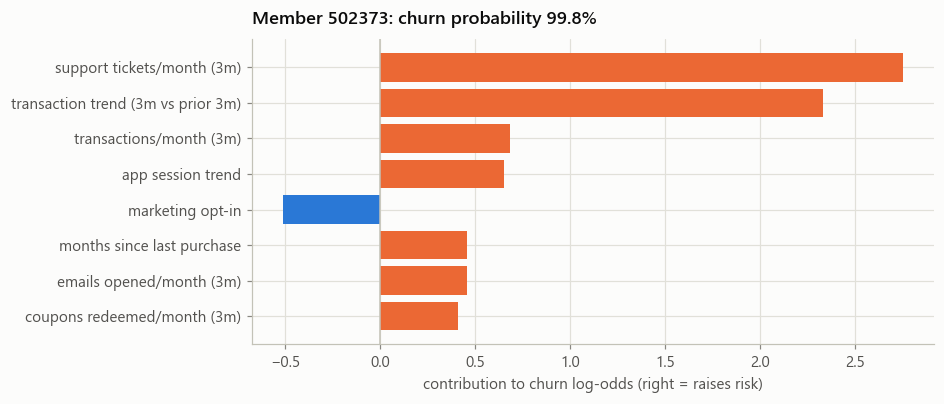

In [4]:
CUSTOMER_ID = int(act.customer_id.iloc[0])
snap = FE.load_snapshots()[str(C.OFFICIAL_CUTOFF.date())].set_index("CUSTOMER_ID")
art = joblib.load(P.models / "logreg_test.joblib")
X = snap.loc[[CUSTOMER_ID], art["features"]]
c = FM.lr_contributions(art["model"], X).iloc[0]
c = c[c.abs().sort_values(ascending=False).index[:8]].iloc[::-1]
fig_, ax = plt.subplots(figsize=(8, 3.6))
ax.barh([FM.NAMES.get(k, k) for k in c.index], c.values, color=[pl.SECOND if v > 0 else pl.ACCENT for v in c.values])
ax.axvline(0, color=pl.BASELINE, lw=1)
ax.set_xlabel("contribution to churn log-odds (right = raises risk)")
ax.set_title(f"Member {CUSTOMER_ID}: churn probability {art['model'].predict_proba(X)[:, 1][0]:.1%}")
plt.show()

## 4. Live what-if for the riskiest active members (Jul-Sep 2024 scores)
The model learned that engaged members churn less; it did not learn what happens when we *cause* engagement. These
numbers rank what to test with a hold-out group.

In [5]:
ACTION = "C. engagement outreach (app + email)"   # or "A. proactive support outreach", "B. targeted coupon"
GAP_SHARE = 0.5                                   # share of the retained-vs-churned behaviour gap closed (0.25 / 0.5 / 1.0)
TARGET_SHARE = 0.20
snaps = FE.load_snapshots()
prod = joblib.load(P.models / "logreg_production.joblib")
gaps, ref = SC.behaviour_gaps(snaps)
sc = snaps[str(C.SCORING_CUTOFF.date())]
now = sc[sc.active_at_cutoff].copy()
now["p"] = prod["model"].predict_proba(now[prod["features"]])[:, 1]
target = now.sort_values("p", ascending=False).head(round(TARGET_SHARE * len(now)))
changed, eligible = SC.apply_action(target[prod["features"]], SC.ACTIONS[ACTION], gaps, ref, GAP_SHARE)
p_new = prod["model"].predict_proba(changed)[:, 1]
e = eligible.values
print(f"targeted {len(target)} of {len(now)} active members; the action applies to {e.sum()} ({SC.ACTIONS[ACTION]['who']})")
print(f"mean predicted risk of those members: {target.p.values[e].mean():.1%} -> {p_new[e].mean():.1%}")
print(f"expected churners in the target group: {target.p.sum():.0f} -> {p_new.sum():.0f} (model-based, not causal)")

targeted 331 of 1657 active members; the action applies to 331 (members below the retained-member average for app sessions or emails opened)
mean predicted risk of those members: 39.6% -> 29.4%
expected churners in the target group: 131 -> 97 (model-based, not causal)
